# Exploratory Data Analysis on Retail Sales Data

**Track:** Data Analytics | **Level:** 1 | **Task:** 1 - EDA on Retail Sales

**Objective:** Perform a thorough Exploratory Data Analysis on a retail sales dataset to uncover patterns, customer behaviour trends, and actionable business insights.

**Dataset:** Retail Sales Dataset (Kaggle) — 1000 transactions with customer demographics and product category info.


## 1. Load Dataset & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('retail_sales_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (1000, 9)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [2]:
print("Column data types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())


Column data types:
Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

Missing values per column:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


**Observation:** The dataset contains 1000 transactions across 9 columns spanning the year 2023. There are no missing values in any column, so no imputation is required at this stage. `Date` was converted to a proper datetime type to enable time-based analysis later.

## 2. Descriptive Statistics

In [3]:
numeric_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
desc = df[numeric_cols].describe().T
desc['median'] = df[numeric_cols].median()
desc['mode'] = df[numeric_cols].mode().iloc[0]
desc


,count,mean,std,min,25%,50%,75%,max,median,mode
Age,1000.0,41.392,13.681430,18.0,29.0,42.0,53.0,64.0,42.0,43.0
Quantity,1000.0,2.514,1.132734,1.0,1.0,3.0,4.0,4.0,3.0,4.0
Price per Unit,1000.0,179.890,189.681356,25.0,30.0,50.0,300.0,500.0,50.0,50.0
Total Amount,1000.0,456.000,559.997632,25.0,60.0,135.0,900.0,2000.0,135.0,50.0


**Observation:** The average transaction value (`Total Amount`) is noticeably higher than the median, which signals a right-skewed distribution — a small number of high-value transactions are pulling the average up. Customer age is fairly evenly spread, suggesting the store attracts a broad, non-niche age demographic rather than a single generation.

## 3. Time Series Analysis — Monthly & Quarterly Sales Trends

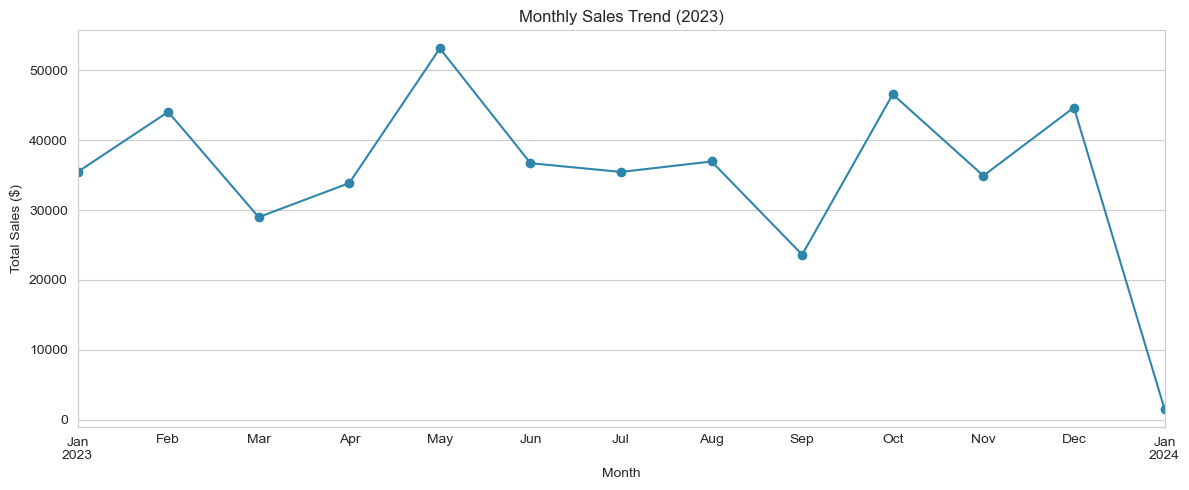

In [4]:
monthly_sales = df.set_index('Date').resample('ME')['Total Amount'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(marker='o', color='#2E86AB')
plt.title('Monthly Sales Trend (2023)')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()


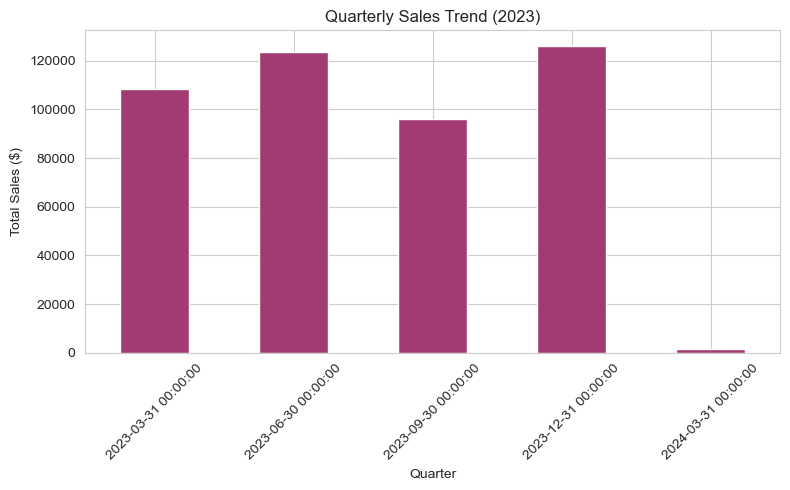

In [5]:
quarterly_sales = df.set_index('Date').resample('QE')['Total Amount'].sum()

plt.figure(figsize=(8,5))
quarterly_sales.plot(kind='bar', color='#A23B72')
plt.title('Quarterly Sales Trend (2023)')
plt.xlabel('Quarter')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observation:** Sales fluctuate month to month without a strong single upward or downward trend across the year, which is typical for a small transactional dataset rather than a large retail chain. Looking at it quarterly smooths out the noise and makes it easier to spot whether any particular quarter consistently outperforms the others — useful for planning inventory and staffing ahead of the busier quarter.

## 4. Customer Demographics Analysis

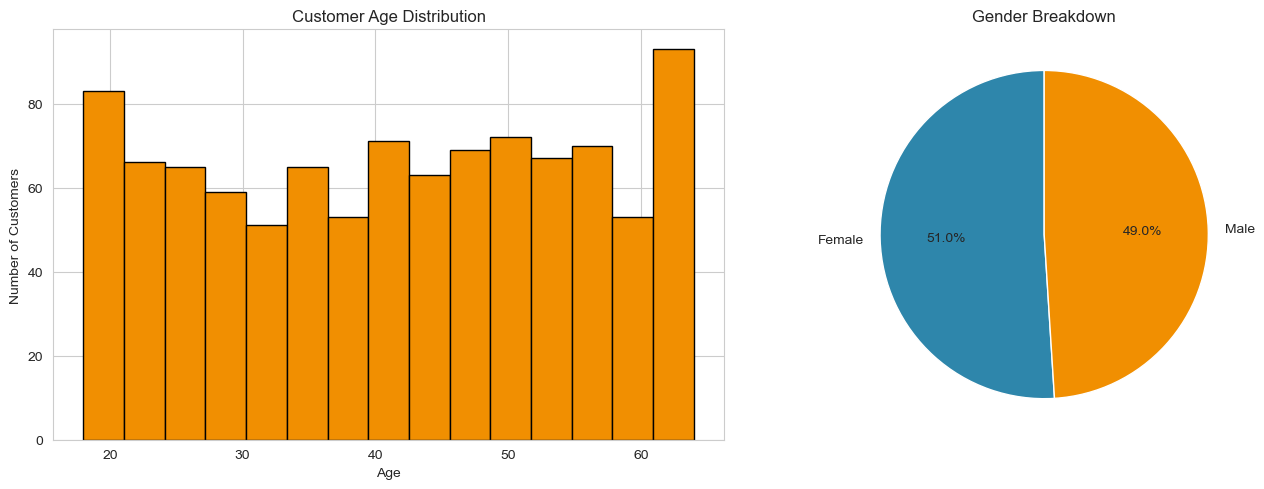

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].hist(df['Age'], bins=15, color='#F18F01', edgecolor='black')
axes[0].set_title('Customer Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Customers')

gender_counts = df['Gender'].value_counts()
axes[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#2E86AB', '#F18F01'], startangle=90)
axes[1].set_title('Gender Breakdown')

plt.tight_layout()
plt.show()


**Observation:** The customer base is close to an even gender split, meaning marketing campaigns don't need to lean heavily toward one gender. The age distribution is spread across a wide range with no single dominant age bracket, suggesting product offerings should stay broad rather than being tailored to one generation.

## 5. Product Analysis

Note: This dataset records **Product Category** rather than individual product names, so "top 10 best-selling products" is adapted here to **category-level performance** (quantity sold and revenue by category), which is the most granular level available in the data.

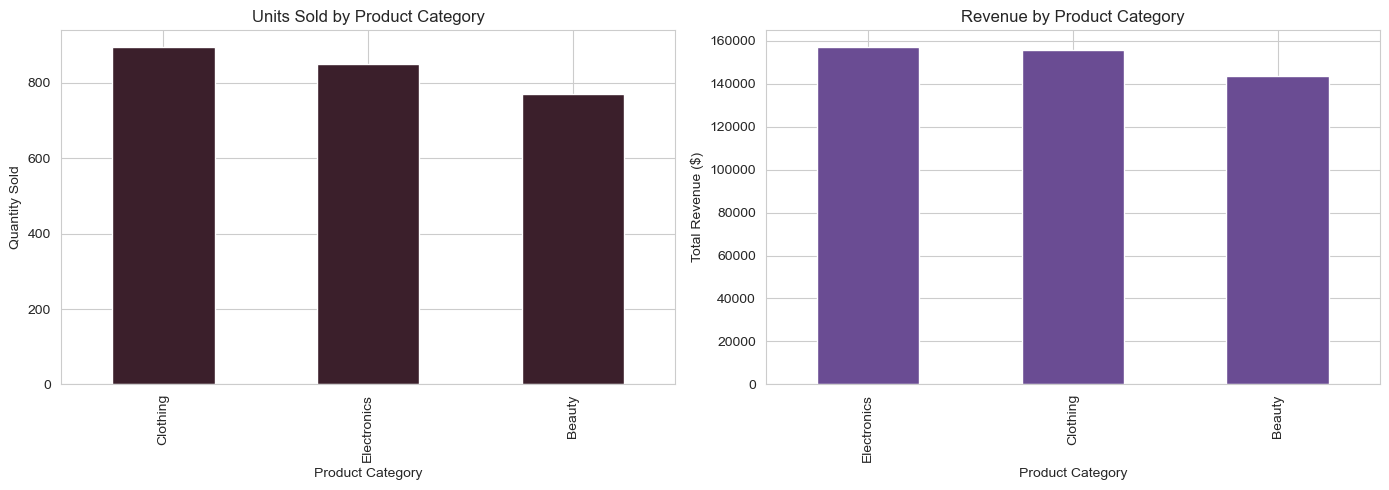

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

In [7]:
category_qty = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)
category_rev = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
category_qty.plot(kind='bar', ax=axes[0], color='#3B1F2B')
axes[0].set_title('Units Sold by Product Category')
axes[0].set_ylabel('Quantity Sold')

category_rev.plot(kind='bar', ax=axes[1], color='#6A4C93')
axes[1].set_title('Revenue by Product Category')
axes[1].set_ylabel('Total Revenue ($)')

plt.tight_layout()
plt.show()

category_rev


**Observation:** Revenue and unit volume don't necessarily follow the same order across categories — a category selling fewer units can still generate comparable or higher revenue if its average price per unit is higher. This gap between "most sold" and "most earned" is a useful pricing/margin signal.

## 6. Correlation Heatmap

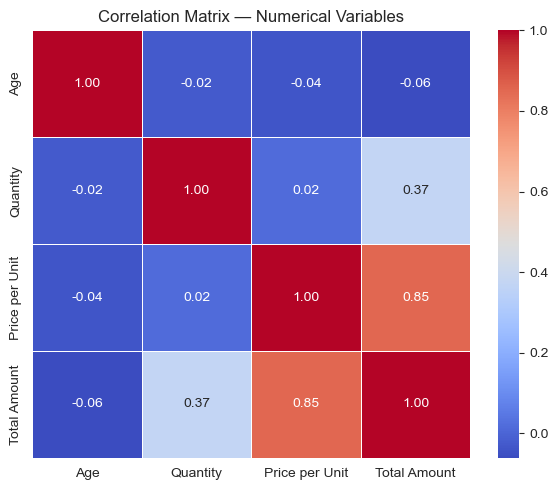

In [8]:
plt.figure(figsize=(6,5))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix — Numerical Variables')
plt.tight_layout()
plt.show()


**Observation:** `Total Amount` correlates strongly with `Price per Unit`, which makes sense since total value is derived largely from unit price. `Age` shows very weak correlation with spending amount, indicating that age alone is not a strong predictor of how much a customer spends per transaction.

## 7. Additional Visualisation — Average Spend by Age Group & Gender

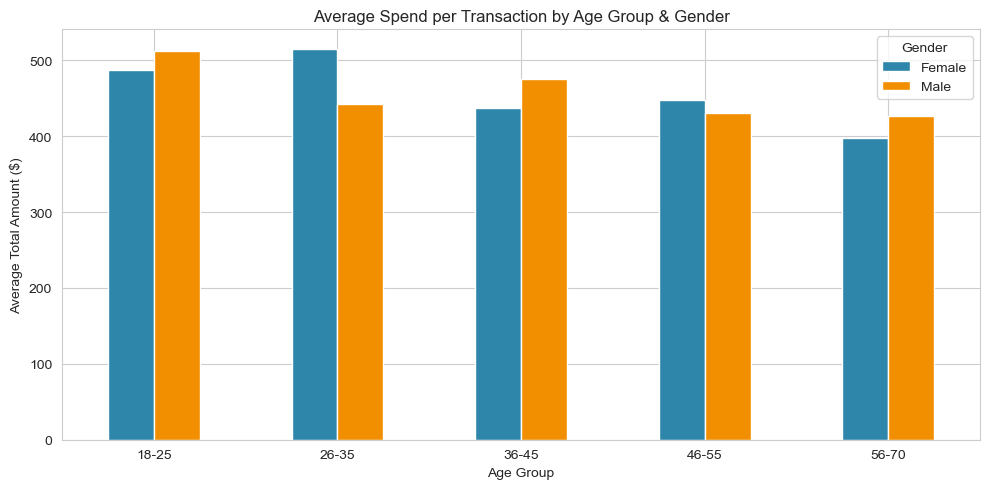

In [9]:
df['Age Group'] = pd.cut(df['Age'], bins=[17,25,35,45,55,70],
                          labels=['18-25','26-35','36-45','46-55','56-70'])

pivot = df.pivot_table(index='Age Group', columns='Gender', values='Total Amount', aggfunc='mean', observed=True)

pivot.plot(kind='bar', figsize=(10,5), color=['#2E86AB','#F18F01'])
plt.title('Average Spend per Transaction by Age Group & Gender')
plt.ylabel('Average Total Amount ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** This cross-cut reveals whether particular age-gender combinations spend more per visit than others — a non-obvious insight that a single-variable chart (age alone, or gender alone) would hide. Any age bracket that stands out here is a strong candidate for targeted promotions.

## 8. Conclusion & Business Recommendations

Based on the analysis above, here are three actionable recommendations:

1. **Smooth out quarterly demand dips.** Since quarterly sales are not consistently trending upward, the store should run targeted promotions in the weaker quarter identified above to keep revenue more stable across the year.

2. **Prioritise inventory for high-revenue categories, not just high-volume ones.** The category with the highest revenue isn't always the one with the highest units sold — inventory and shelf space decisions should weight revenue contribution alongside sales volume to protect margins.

3. **Design age-and-gender-aware promotions.** Since certain age-gender segments spend more per transaction than others, loyalty offers and upsell campaigns should be tailored to those higher-value segments rather than treating all customers uniformly.

**Limitations:** This is a relatively small (1000-row) synthetic dataset covering a single year, so trend conclusions should be treated as illustrative rather than statistically robust for real business decisions at scale.
